# Курсовая работа: Предсказание возраста моллюсков

## Задача
Предсказать количество колец (Rings) моллюсков, что соответствует их возрасту.

## План работы
1. Загрузка и предобработка данных
2. Создание новых признаков
3. Обучение модели Random Forest Regressor
4. Оценка качества модели
5. Предсказание на тестовом датасете

## 1. Импорт библиотек

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Загрузка данных

In [21]:
# Загрузка тренировочных данных
train_df = pd.read_csv('data/train.csv')
print(f"Размер тренировочного датасета: {train_df.shape}")
print("\nПервые строки:")
train_df.head()

Размер тренировочного датасета: (90615, 10)

Первые строки:


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [22]:
# Загрузка тестовых данных
test_df = pd.read_csv('data/test.csv')
print(f"Размер тестового датасета: {test_df.shape}")
print("\nПервые строки:")
test_df.head()

Размер тестового датасета: (60411, 9)

Первые строки:


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050


In [23]:
# Информация о данных
print("Информация о тренировочных данных:")
train_df.info()

print("\n" + "="*70)
print("Статистика:")
train_df.describe()

Информация о тренировочных данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB

Статистика:


,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000
mean,45307.000000,0.517098,0.401679,0.135464,0.789035,0.340778,0.169422,0.225898,9.696794
std,26158.441658,0.118217,0.098026,0.038008,0.457671,0.204428,0.100909,0.130203,3.176221
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,22653.500000,0.445000,0.345000,0.110000,0.419000,0.177500,0.086500,0.120000,8.000000
50%,45307.000000,0.545000,0.425000,0.140000,0.799500,0.330000,0.166000,0.225000,9.000000
75%,67960.500000,0.600000,0.470000,0.160000,1.067500,0.463000,0.232500,0.305000,11.000000
max,90614.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


## 3. Предобработка данных

На основе EDA анализа выполним:
1. Кодирование категориального признака Sex
2. Создание новых признаков (Volume, Surface Area, Ratios)
3. Обработка мультиколлинеарности
4. Масштабирование признаков

In [24]:
def preprocess_data(df, is_train=True):
    """ 
    Parameters:
    -----------
    df : pandas.DataFrame
        Исходный датасет
    is_train : bool
        Флаг, указывающий является ли это тренировочным датасетом
    
    Returns:
    --------
    pandas.DataFrame
        Предобработанный датасет
    """
    df_processed = df.copy()
    
    # 1. Создание новых признаков
    
    # Объемные метрики
    df_processed['Volume'] = (df_processed['Length'] * 
                               df_processed['Diameter'] * 
                               df_processed['Height'])
    
    df_processed['Surface_Area'] = 2 * (
        df_processed['Length'] * df_processed['Diameter'] + 
        df_processed['Length'] * df_processed['Height'] + 
        df_processed['Diameter'] * df_processed['Height']
    )
    
    # Соотношения размеров
    df_processed['Length_to_Diameter'] = df_processed['Length'] / (df_processed['Diameter'] + 1e-6)
    df_processed['Height_to_Length'] = df_processed['Height'] / (df_processed['Length'] + 1e-6)
    df_processed['Height_to_Diameter'] = df_processed['Height'] / (df_processed['Diameter'] + 1e-6)
    
    # Весовые соотношения
    df_processed['Meat_ratio'] = df_processed['Whole weight.1'] / (df_processed['Whole weight'] + 1e-6)
    df_processed['Viscera_ratio'] = df_processed['Whole weight.2'] / (df_processed['Whole weight'] + 1e-6)
    df_processed['Shell_ratio'] = df_processed['Shell weight'] / (df_processed['Whole weight'] + 1e-6)
    
    # Плотность
    df_processed['Density'] = df_processed['Whole weight'] / (df_processed['Volume'] + 1e-6)
    
    # Общий вес без раковины
    df_processed['Meat_total'] = (df_processed['Whole weight.1'] + 
                                   df_processed['Whole weight.2'])
        
    # 2. Кодирование категориального признака Sex
    
    # One-Hot Encoding для Sex
    sex_dummies = pd.get_dummies(df_processed['Sex'], prefix='Sex', drop_first=False)
    df_processed = pd.concat([df_processed, sex_dummies], axis=1)
    df_processed.drop('Sex', axis=1, inplace=True)
        
    # 3. Удаление сильно коррелирующих признаков (обработка мультиколлинеарности)
    
    # На основе EDA: Length и Diameter почти идентичны (r=0.9897)
    # Whole weight, Whole weight.1, Whole weight.2 сильно коррелируют
    # Оставим наиболее информативные признаки
    
    features_to_drop = [
        'Length',  # Оставляем Diameter (более коррелирует с целевой)
        'Whole weight.1',  # Уже учтено в Meat_ratio
        'Whole weight.2',  # Уже учтено в Viscera_ratio
    ]
    
    df_processed.drop(features_to_drop, axis=1, inplace=True)
    print(f"   Удалено {len(features_to_drop)} коррелирующих признаков")
    
    # 4. Удаление id (не информативен для модели)
    if 'id' in df_processed.columns:
        df_processed.drop('id', axis=1, inplace=True)
        print("Удален признак 'id'")
    
    return df_processed

# Применяем предобработку
print("="*70)
print("ПРЕДОБРАБОТКА ТРЕНИРОВОЧНЫХ ДАННЫХ")
print("="*70)
train_processed = preprocess_data(train_df, is_train=True)

print("\n" + "="*70)
print("ПРЕДОБРАБОТКА ТЕСТОВЫХ ДАННЫХ")
print("="*70)
test_processed = preprocess_data(test_df, is_train=False)

print("\n" + "="*70)
print(f"Размер обработанного train: {train_processed.shape}")
print(f"Размер обработанного test: {test_processed.shape}")
print("="*70)

ПРЕДОБРАБОТКА ТРЕНИРОВОЧНЫХ ДАННЫХ


   Удалено 3 коррелирующих признаков
Удален признак 'id'

ПРЕДОБРАБОТКА ТЕСТОВЫХ ДАННЫХ
   Удалено 3 коррелирующих признаков
Удален признак 'id'

Размер обработанного train: (90615, 18)
Размер обработанного test: (60411, 17)


In [25]:
# Просмотр обработанных данных
print("Обработанные признаки:")
print(train_processed.columns.tolist())
print(f"\nВсего признаков: {train_processed.shape[1]}")

print("\nПервые строки обработанных данных:")
train_processed.head()

Обработанные признаки:
['Diameter', 'Height', 'Whole weight', 'Shell weight', 'Rings', 'Volume', 'Surface_Area', 'Length_to_Diameter', 'Height_to_Length', 'Height_to_Diameter', 'Meat_ratio', 'Viscera_ratio', 'Shell_ratio', 'Density', 'Meat_total', 'Sex_F', 'Sex_I', 'Sex_M']

Всего признаков: 18

Первые строки обработанных данных:


,Diameter,Height,Whole weight,Shell weight,Rings,Volume,Surface_Area,Length_to_Diameter,Height_to_Length,Height_to_Diameter,Meat_ratio,Viscera_ratio,Shell_ratio,Density,Meat_total,Sex_F,Sex_I,Sex_M
0,0.430,0.150,0.7715,0.2400,11,0.035475,0.76700,1.279067,0.272727,0.348836,0.425793,0.189890,0.311082,21.747097,0.4750,True,False,False
1,0.490,0.145,1.1300,0.3200,11,0.044761,0.94220,1.285712,0.230158,0.295918,0.405309,0.244690,0.283186,25.244345,0.7345,True,False,False
2,0.110,0.025,0.0210,0.0050,6,0.000440,0.04870,1.454532,0.156249,0.227271,0.261892,0.142850,0.238084,47.619048,0.0085,False,True,False
3,0.475,0.150,0.9145,0.2500,10,0.042394,0.88625,1.252629,0.252100,0.315789,0.410606,0.224713,0.273373,21.571067,0.5810,False,False,True
4,0.425,0.130,0.7820,0.1975,9,0.030664,0.72655,1.305879,0.234234,0.305882,0.472506,0.204603,0.252557,25.501594,0.5295,False,True,False


## 4. Разделение данных на признаки и целевую переменную

In [26]:
# Разделение на X и y
X = train_processed.drop('Rings', axis=1)
y = train_processed['Rings']

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"\nПризнаки для обучения ({X.shape[1]}):")
print(X.columns.tolist())

Размер X: (90615, 17)
Размер y: (90615,)

Признаки для обучения (17):
['Diameter', 'Height', 'Whole weight', 'Shell weight', 'Volume', 'Surface_Area', 'Length_to_Diameter', 'Height_to_Length', 'Height_to_Diameter', 'Meat_ratio', 'Viscera_ratio', 'Shell_ratio', 'Density', 'Meat_total', 'Sex_F', 'Sex_I', 'Sex_M']


In [27]:
# Разделение на train и validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Размеры после разделения:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val: {y_val.shape}")

Размеры после разделения:
X_train: (72492, 17)
X_val: (18123, 17)
y_train: (72492,)
y_val: (18123,)


## 5. Обучение модели Random Forest Regressor

In [28]:
# Создание модели с оптимальными гиперпараметрами
rf_model = RandomForestRegressor(
    n_estimators=200,       # Количество деревьев
    max_depth=15,           # Максимальная глубина деревьев
    min_samples_split=5,    # Минимальное количество сэмплов для разделения узла
    min_samples_leaf=6,     # Минимальное количество сэмплов в листе
    max_features='log2',    # Количество признаков для рассмотрения при разделении
    random_state=42,
    n_jobs=-1,              # Использовать все ядра процессора
    verbose=1
)

# Обучение модели
rf_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   12.2s finished


,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6. Оценка качества модели

In [29]:
# Предсказания на тренировочной выборке
y_train_pred = rf_model.predict(X_train)

# Предсказания на валидационной выборке
y_val_pred = rf_model.predict(X_val)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.2s finished


In [30]:
def calculate_rmsle(y_true, y_pred):
    """
    Расчет Root Mean Squared Logarithmic Error (RMSLE)
    
    RMSLE = sqrt(mean((log(y_pred + 1) - log(y_true + 1))^2))
    """
    # Убедимся, что нет отрицательных значений
    y_pred = np.maximum(y_pred, 0)
    
    log_pred = np.log1p(y_pred)  # log(1 + y_pred)
    log_true = np.log1p(y_true)  # log(1 + y_true)
    
    squared_log_error = (log_pred - log_true) ** 2
    rmsle = np.sqrt(np.mean(squared_log_error))
    
    return rmsle

# Расчет метрик
def evaluate_model(y_true, y_pred, dataset_name=""):
    """
    Расчет всех метрик качества
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = calculate_rmsle(y_true, y_pred)
    
    print(f"\nМетрики на {dataset_name}:")
    print("="*70)
    print(f"RMSE (Root Mean Squared Error):              {rmse:.4f}")
    print(f"MAE (Mean Absolute Error):                   {mae:.4f}")
    print(f"R² Score:                                    {r2:.4f}")
    print(f"RMSLE (Root Mean Squared Logarithmic Error): {rmsle:.4f}")
    print("="*70)
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'RMSLE': rmsle
    }

# Оценка на тренировочной выборке
train_metrics = evaluate_model(y_train, y_train_pred, "тренировочной выборке")

# Оценка на валидационной выборке
val_metrics = evaluate_model(y_val, y_val_pred, "валидационной выборке")


Метрики на тренировочной выборке:
RMSE (Root Mean Squared Error):              1.5163
MAE (Mean Absolute Error):                   1.0336
R² Score:                                    0.7710
RMSLE (Root Mean Squared Logarithmic Error): 0.1247

Метрики на валидационной выборке:
RMSE (Root Mean Squared Error):              1.8783
MAE (Mean Absolute Error):                   1.2685
R² Score:                                    0.6566
RMSLE (Root Mean Squared Logarithmic Error): 0.1528


In [31]:
# Сравнение метрик
metrics_df = pd.DataFrame([train_metrics, val_metrics], index=['Train', 'Validation']).T

print("\nСравнение метрик:")
print(metrics_df)



Сравнение метрик:
          Train  Validation
RMSE   1.516303    1.878306
MAE    1.033640    1.268461
R2     0.771050    0.656551
RMSLE  0.124734    0.152826


## 7. Важность признаков


Топ-15 наиболее важных признаков:
           Feature  Importance
      Shell weight    0.185686
        Meat_ratio    0.134261
      Whole weight    0.126150
            Height    0.104206
            Volume    0.088892
          Diameter    0.067793
       Shell_ratio    0.063173
      Surface_Area    0.060018
        Meat_total    0.048561
  Height_to_Length    0.032418
             Sex_I    0.017736
     Viscera_ratio    0.017566
Height_to_Diameter    0.017456
Length_to_Diameter    0.015258
           Density    0.014891


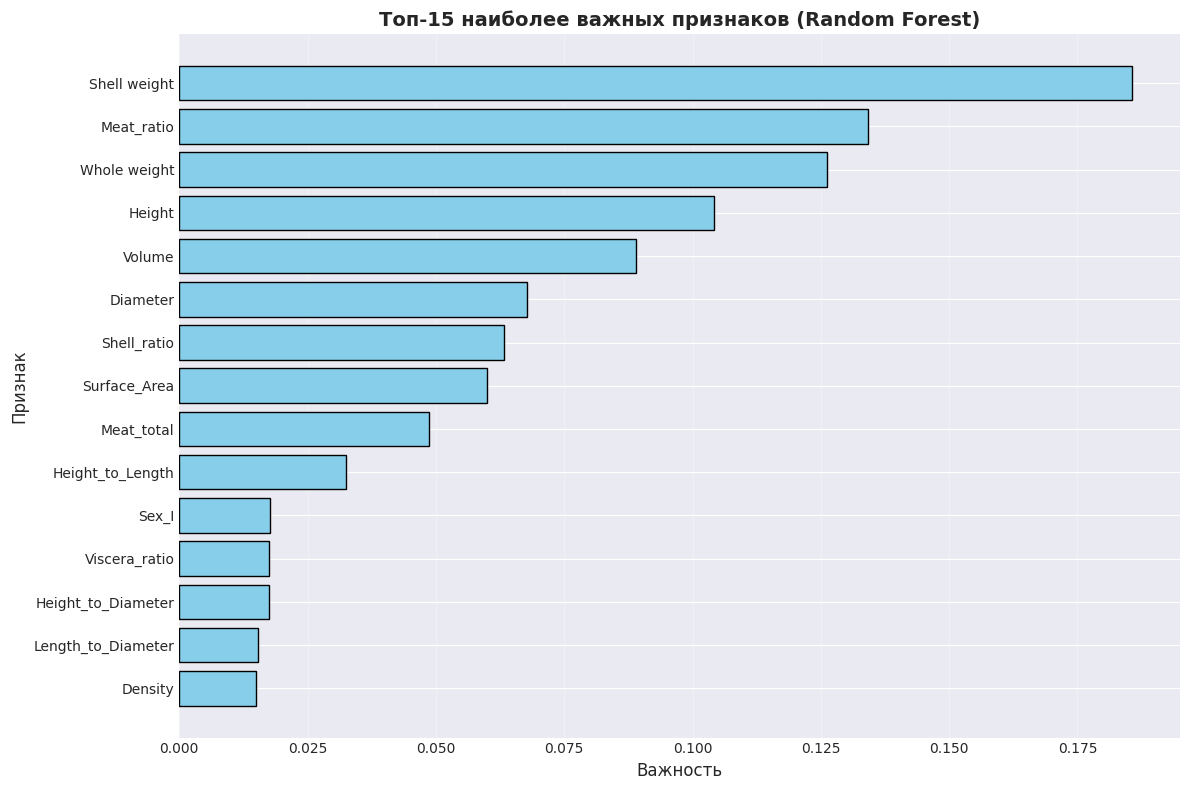

In [32]:
# Извлечение важности признаков
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nТоп-15 наиболее важных признаков:")
print("="*70)
print(feature_importance.head(15).to_string(index=False))

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title('Топ-15 наиболее важных признаков (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Визуализация результатов

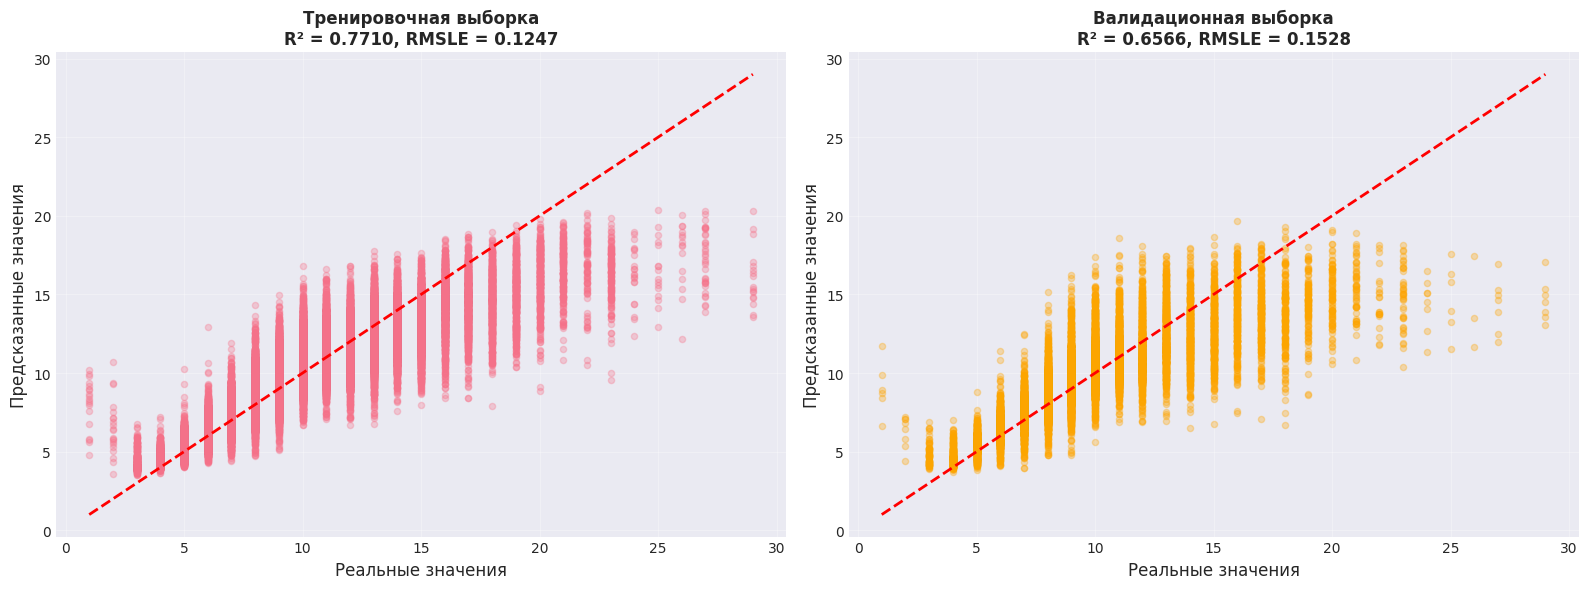

In [33]:
# График предсказаний vs реальных значений
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Тренировочная выборка
axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Реальные значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f'Тренировочная выборка\nR² = {train_metrics["R2"]:.4f}, RMSLE = {train_metrics["RMSLE"]:.4f}', 
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Валидационная выборка
axes[1].scatter(y_val, y_val_pred, alpha=0.3, s=20, color='orange')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Реальные значения', fontsize=12)
axes[1].set_ylabel('Предсказанные значения', fontsize=12)
axes[1].set_title(f'Валидационная выборка\nR² = {val_metrics["R2"]:.4f}, RMSLE = {val_metrics["RMSLE"]:.4f}', 
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

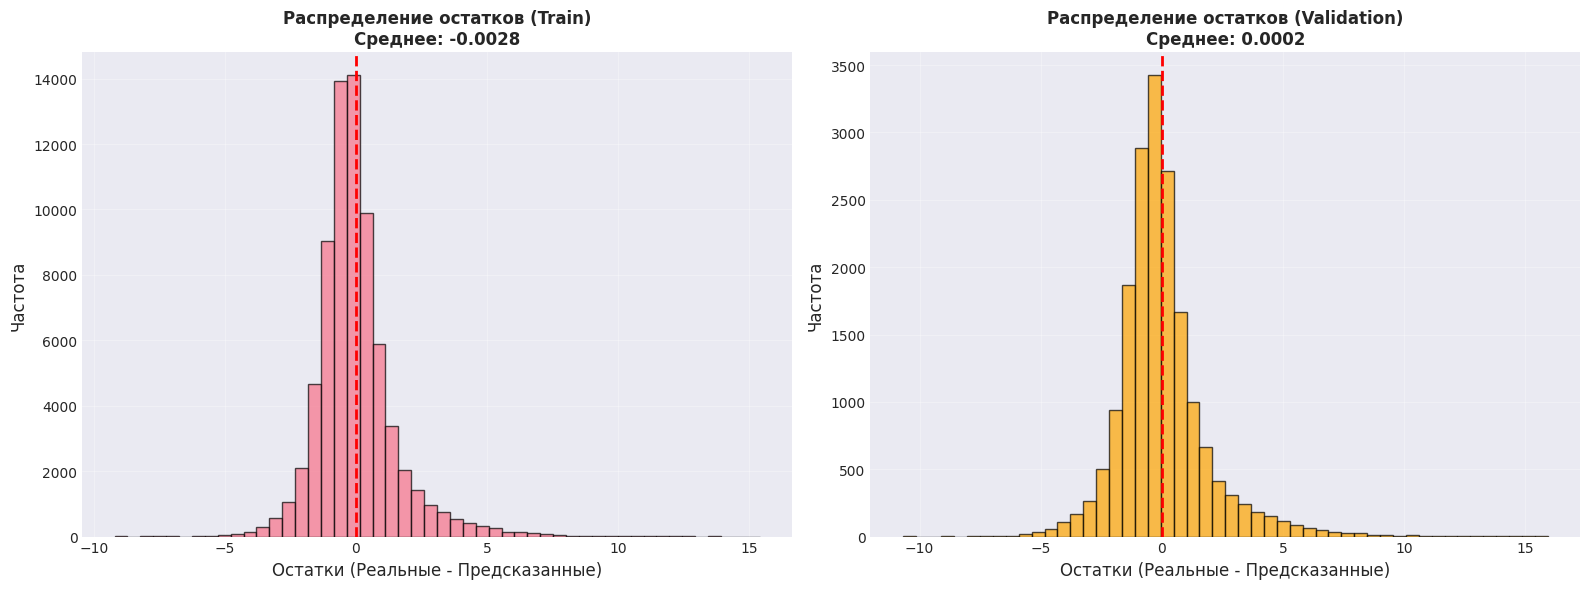

In [34]:
# Распределение ошибок
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Остатки (residuals)
train_residuals = y_train - y_train_pred
val_residuals = y_val - y_val_pred

# Гистограмма остатков - тренировочная
axes[0].hist(train_residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Остатки (Реальные - Предсказанные)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title(f'Распределение остатков (Train)\nСреднее: {train_residuals.mean():.4f}', 
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Гистограмма остатков - валидационная
axes[1].hist(val_residuals, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Остатки (Реальные - Предсказанные)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение остатков (Validation)\nСреднее: {val_residuals.mean():.4f}', 
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Предсказание на тестовом датасете

In [35]:
# Подготовка тестовых данных
X_test = test_processed.copy()

# Убедимся, что у нас те же признаки, что и при обучении
print("Проверка соответствия признаков:")
print(f"Признаков в train: {len(X_train.columns)}")
print(f"Признаков в test: {len(X_test.columns)}")

# Проверка на отсутствующие признаки
missing_features = set(X_train.columns) - set(X_test.columns)
extra_features = set(X_test.columns) - set(X_train.columns)

if missing_features:
    print(f"\n Отсутствующие признаки в test: {missing_features}")
    for feature in missing_features:
        X_test[feature] = 0

if extra_features:
    print(f"\n Лишние признаки в test: {extra_features}")
    X_test = X_test.drop(columns=list(extra_features))

# Упорядочим признаки так же, как в тренировочной выборке
X_test = X_test[X_train.columns]

print("\nПризнаки согласованы")
print(f"Размер X_test: {X_test.shape}")

Проверка соответствия признаков:
Признаков в train: 17
Признаков в test: 17

Признаки согласованы
Размер X_test: (60411, 17)


Выполняю предсказания на тестовом датасете...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.4s finished



Статистика предсказаний:
Минимум: 3.66
Максимум: 19.38
Среднее: 9.71
Медиана: 9.56


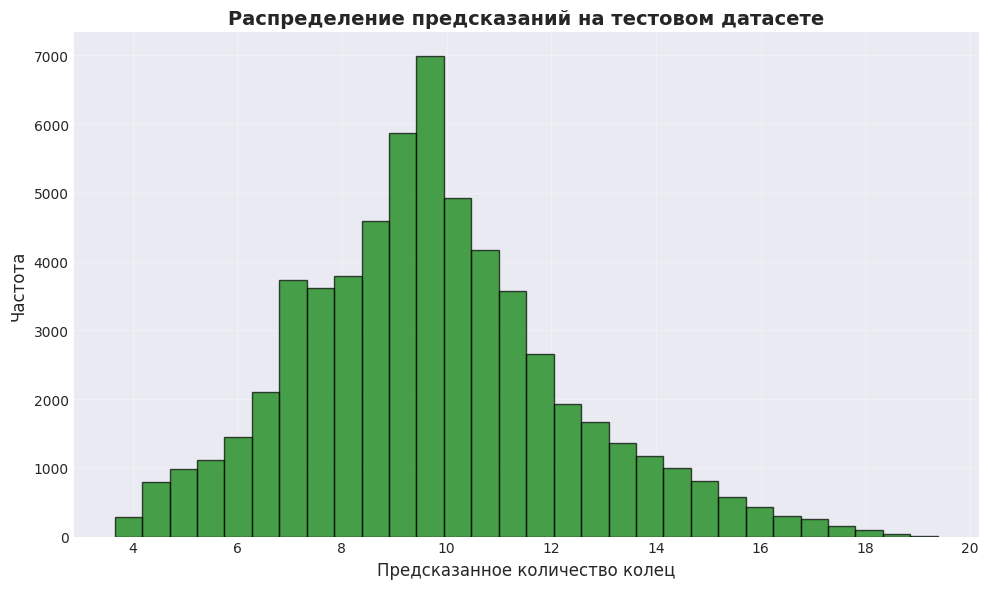

In [36]:
# Предсказание на тестовом датасете
print("Выполняю предсказания на тестовом датасете...")
y_test_pred = rf_model.predict(X_test)

# Убедимся, что предсказания неотрицательные
y_test_pred = np.maximum(y_test_pred, 0)

print("\nСтатистика предсказаний:")
print(f"Минимум: {y_test_pred.min():.2f}")
print(f"Максимум: {y_test_pred.max():.2f}")
print(f"Среднее: {y_test_pred.mean():.2f}")
print(f"Медиана: {np.median(y_test_pred):.2f}")

# Визуализация распределения предсказаний
plt.figure(figsize=(10, 6))
plt.hist(y_test_pred, bins=30, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Предсказанное количество колец', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение предсказаний на тестовом датасете', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Создание файла с предсказаниями для submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'Rings': y_test_pred
})

# Сохранение в CSV
submission.to_csv('submission.csv', index=False)

print("\nФайл submission.csv создан")
print(f"\nПервые 10 строк submission:")
print(submission.head(10))
print(f"\nВсего предсказаний: {len(submission)}")


Файл submission.csv создан

Первые 10 строк submission:
      id      Rings
0  90615   9.731430
1  90616   9.887140
2  90617  10.048594
3  90618  10.539353
4  90619   7.591627
5  90620   9.176048
6  90621  11.406866
7  90622   6.300617
8  90623   7.975186
9  90624  11.442067

Всего предсказаний: 60411


## 10. Итоговый отчет

In [38]:
print("="*70)
print("ИТОГОВЫЙ ОТЧЕТ")
print("="*70)

print("\n1. МОДЕЛЬ:")
print("   Random Forest Regressor")
print(f"   - n_estimators: {rf_model.n_estimators}")
print(f"   - max_depth: {rf_model.max_depth}")
print(f"   - min_samples_split: {rf_model.min_samples_split}")

print("\n2. ДАННЫЕ:")
print(f"   - Тренировочная выборка: {X_train.shape[0]} записей")
print(f"   - Валидационная выборка: {X_val.shape[0]} записей")
print(f"   - Тестовая выборка: {X_test.shape[0]} записей")
print(f"   - Количество признаков: {X_train.shape[1]}")

print("\n3. МЕТРИКИ КАЧЕСТВА (ВАЛИДАЦИЯ):")
print(f"   - RMSE: {val_metrics['RMSE']:.4f}")
print(f"   - MAE: {val_metrics['MAE']:.4f}")
print(f"   - R² Score: {val_metrics['R2']:.4f}")
print(f"   - RMSLE: {val_metrics['RMSLE']:.4f} ")

print("\n4. ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

print("\n5. ПРЕДСКАЗАНИЯ НА ТЕСТЕ:")
print(f"   - Среднее значение: {y_test_pred.mean():.2f} колец")
print(f"   - Диапазон: {y_test_pred.min():.2f} - {y_test_pred.max():.2f}")
print(f"   - Файл: submission.csv")

ИТОГОВЫЙ ОТЧЕТ

1. МОДЕЛЬ:
   Random Forest Regressor
   - n_estimators: 200
   - max_depth: 15
   - min_samples_split: 5

2. ДАННЫЕ:
   - Тренировочная выборка: 72492 записей
   - Валидационная выборка: 18123 записей
   - Тестовая выборка: 60411 записей
   - Количество признаков: 17

3. МЕТРИКИ КАЧЕСТВА (ВАЛИДАЦИЯ):
   - RMSE: 1.8783
   - MAE: 1.2685
   - R² Score: 0.6566
   - RMSLE: 0.1528 

4. ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
   Shell weight: 0.1857
   Meat_ratio: 0.1343
   Whole weight: 0.1261
   Height: 0.1042
   Volume: 0.0889

5. ПРЕДСКАЗАНИЯ НА ТЕСТЕ:
   - Среднее значение: 9.71 колец
   - Диапазон: 3.66 - 19.38
   - Файл: submission.csv
